In [163]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep as mh
from matplotlib.colors import LogNorm
import math
mh.style.use("ATLAS")
import particle
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [164]:
mc_CaloNu_events = uproot.concatenate("build/MC_new_truth/2024_CaloNu.bck.root:nt", library="ak")

In [165]:
mc_FaserNu_events = uproot.concatenate("build/MC_new_truth/2024_noCaloNu.bck.root:nt", library="ak")

In [166]:
def get_truth_matched_fraction(ak_record):
    truth_matched_events = []
    not_truth_matched_events = []

    for event in tqdm.tqdm(ak_record):
        # Get index of highest momentum truth matched track and ask if it is a muon from a neutrino interaction
        idx = np.argmax(event["t_pz"])
        truth_matched_pdg = event["t_pdg"][idx]
        truth_matched_parent_pdg = event["t_pdg_parent"][idx]
    
        if abs(truth_matched_pdg) == 13 and abs(truth_matched_parent_pdg) in [12, 14, 16]:
            truth_matched_events.append(event)
        else:
            not_truth_matched_events.append(event)

    return truth_matched_events, not_truth_matched_events, len(truth_matched_events) / len(ak_record), len(not_truth_matched_events) / len(ak_record)

In [167]:
truth_matched_events_caloNu, not_truth_matched_events_caloNu, truth_matched_fraction_caloNu, not_truth_matched_fraction_caloNu = get_truth_matched_fraction(mc_CaloNu_events)

print(f"Fraction of events with 1 long track that are truth matched: {truth_matched_fraction_caloNu:.2%}")
print(f"Fraction of events with 1 long track that are not truth matched: {not_truth_matched_fraction_caloNu:.2%}")

100%|██████████| 22745/22745 [00:13<00:00, 1712.39it/s]

Fraction of events with 1 long track that are truth matched: 95.73%
Fraction of events with 1 long track that are not truth matched: 4.27%


In [168]:
truth_matched_events_faserNu, not_truth_matched_events_faserNu, truth_matched_fraction_faserNu, not_truth_matched_fraction_faserNu = get_truth_matched_fraction(mc_FaserNu_events)

print(f"Fraction of events with 1 long track that are truth matched: {truth_matched_fraction_faserNu:.2%}")
print(f"Fraction of events with 1 long track that are not truth matched: {not_truth_matched_fraction_faserNu:.2%}")

100%|██████████| 43390/43390 [00:25<00:00, 1674.85it/s]

Fraction of events with 1 long track that are truth matched: 97.88%
Fraction of events with 1 long track that are not truth matched: 2.12%


In [169]:
calonu_pdg_of_highest_momentum_not_truth_matched_track = [event["t_pdg"][np.argmax(event["t_pz"])] for event in not_truth_matched_events_caloNu]
faserNu_pdg_of_highest_momentum_not_truth_matched_track = [event["t_pdg"][np.argmax(event["t_pz"])] for event in not_truth_matched_events_faserNu]

In [170]:
def get_particle_names(pdg_list):
    particle_names = []
    for pdg in pdg_list:
        if pdg == 0:
            particle_names.append("Not matched")
            continue

        try:
            particle_names.append("$" + particle.Particle.from_pdgid(pdg).latex_name + "$")
        except ValueError:
            particle_names.append("Unknown")
    return sorted(particle_names)

In [171]:
particles_incorr_matched_caloNu = get_particle_names(calonu_pdg_of_highest_momentum_not_truth_matched_track)
particles_incorr_matched_faserNu = get_particle_names(faserNu_pdg_of_highest_momentum_not_truth_matched_track)

In [172]:
missing_species = sorted(set(particles_incorr_matched_caloNu).union(set(particles_incorr_matched_faserNu)))
print(f"Missing species: {missing_species}")

species_counts = {
    "CaloNu": [0 for _ in range(len(missing_species))],
    "FaserNu": [0 for _ in range(len(missing_species))]
}

for species in missing_species:
    species_counts["CaloNu"][missing_species.index(species)] = particles_incorr_matched_caloNu.count(species)
    species_counts["FaserNu"][missing_species.index(species)] = particles_incorr_matched_faserNu.count(species)


Missing species: ['$K^{+}$', '$K^{-}$', '$\\Sigma^{+}$', '$\\Xi^{-}$', '$\\mu^{+}$', '$\\mu^{-}$', '$\\overline{p}$', '$\\pi^{+}$', '$\\pi^{-}$', '$e^{+}$', '$e^{-}$', '$p$', 'Not matched']


Text(0.05, 0.8, 'CaloNu: 95.73% truth matched\nFASERnu: 97.88% truth matched')

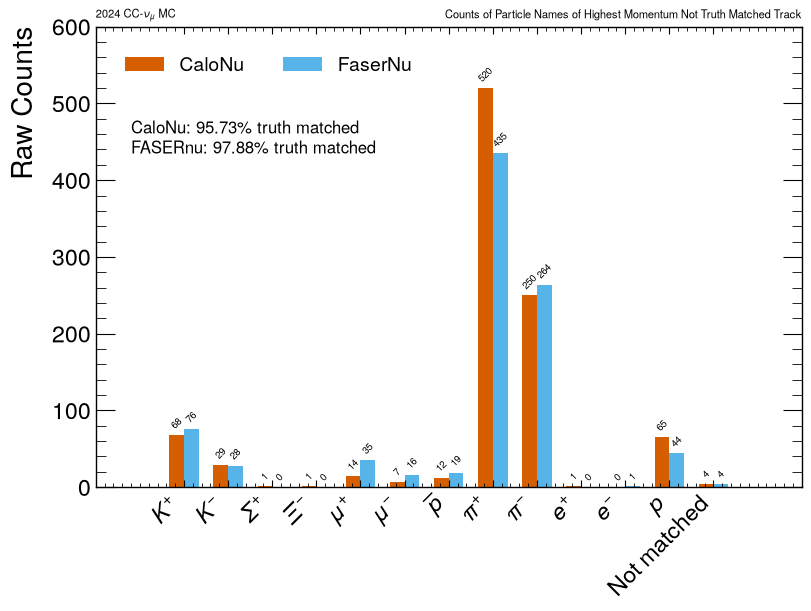

In [173]:
fig, ax = plt.subplots(layout='constrained')

res = ax.grouped_bar(species_counts, tick_labels=missing_species, group_spacing=1)
for container in res.bar_containers:
    ax.bar_label(container, padding=3, fontsize=7, rotation=45)

ax.legend(loc='upper left', ncols=3)
# rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
ax.set_ylabel("Raw Counts")
ax.set_title("Counts of Particle Names of Highest Momentum Not Truth Matched Track", fontsize=8, loc="right")
ax.set_title(r"2024 CC-$\nu_\mu$ MC", loc="left", fontsize=8)

# Print the truth matching fractions for both datasets on the plot
ax.text(0.05, 0.8, f"CaloNu: {truth_matched_fraction_caloNu:.2%} truth matched\nFASERnu: {truth_matched_fraction_faserNu:.2%} truth matched",
        transform=ax.transAxes, fontsize=12, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

In [174]:
events_two_tracks_caloNu = mc_CaloNu_events[mc_CaloNu_events["longTracks"] >= 2]
events_two_tracks_faserNu = mc_FaserNu_events[mc_FaserNu_events["longTracks"] >= 2]

In [175]:
def get_subleading_track_pdg(ak_record):
    subleading_track_pdgs = []
    for event in tqdm.tqdm(ak_record):
        # Get index of highest momentum truth matched track and ask if it is a muon from a neutrino interaction
        idx = np.argsort(event["t_pz"])[-2]  # Get the index of the second highest momentum track
        # print(f"Index of subleading track: {idx}, PDG of subleading track: {event['t_pdg'][idx]}, Tracks pz: {event['t_pz']}, Tracks PDG: {event['t_pdg']}")
        subleading_track_pdgs.append(event["t_pdg"][idx])
    return subleading_track_pdgs

100%|██████████| 2495/2495 [00:01<00:00, 1983.81it/s]


Species of subleading tracks: ['$K^{+}$', '$K^{-}$', '$\\Sigma^{-}$', '$\\mu^{+}$', '$\\mu^{-}$', '$\\overline{\\Sigma}^{+}$', '$\\overline{p}$', '$\\pi^{+}$', '$\\pi^{-}$', '$e^{+}$', '$e^{-}$', '$p$', 'Not matched']


Text(0.0, 1.0, '2024 CC-$\\nu_\\mu$ MC')

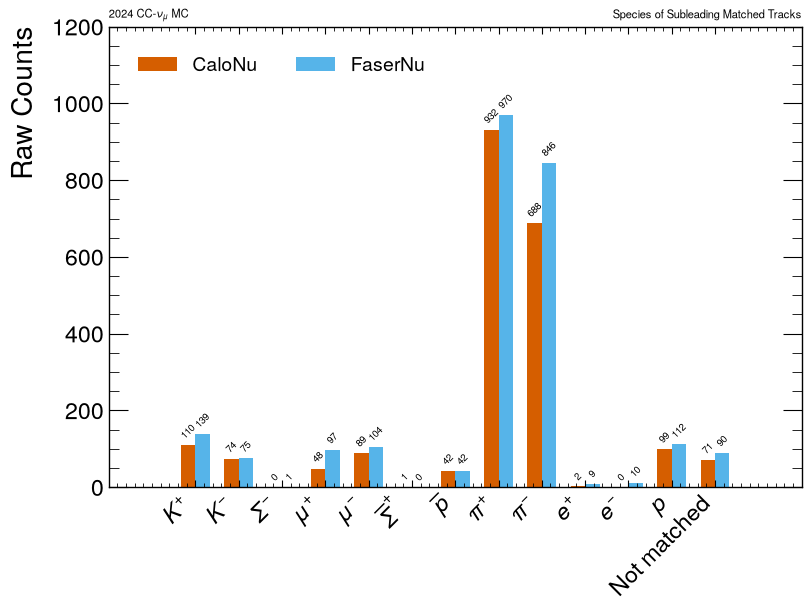

In [176]:
subleading_track_pdgs_caloNu = get_subleading_track_pdg(events_two_tracks_caloNu)
subleading_track_pdgs_faserNu = get_subleading_track_pdg(events_two_tracks_faserNu)

subleading_track_names_caloNu = get_particle_names(subleading_track_pdgs_caloNu)
subleading_track_names_faserNu = get_particle_names(subleading_track_pdgs_faserNu)

species = sorted(set(subleading_track_names_caloNu).union(set(subleading_track_names_faserNu)))
print(f"Species of subleading tracks: {species}")

species_counts_subleading = {
    "CaloNu": [0 for _ in range(len(species))],
    "FaserNu": [0 for _ in range(len(species))]
}
for sp in species:
    species_counts_subleading["CaloNu"][species.index(sp)] = subleading_track_names_caloNu.count(sp)
    species_counts_subleading["FaserNu"][species.index(sp)] = subleading_track_names_faserNu.count(sp)


fig, ax = plt.subplots(layout='constrained')

res = ax.grouped_bar(species_counts_subleading, tick_labels=species, group_spacing=1)
for container in res.bar_containers:
    ax.bar_label(container, padding=3, fontsize=7, rotation=45)

ax.legend(loc='upper left', ncols=3)
# rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
ax.set_ylabel("Raw Counts")
ax.set_title("Species of Subleading Matched Tracks", fontsize=8, loc="right")
ax.set_title(r"2024 CC-$\nu_\mu$ MC", loc="left", fontsize=8)

In [177]:
def get_subleading_track_pdg(ak_record):
    subleading_track_pdgs = []
    for event in tqdm.tqdm(ak_record):
        # Get index of highest momentum truth matched track and ask if it is a muon from a neutrino interaction
        idx = np.argsort(event["t_pz"])[-2]  # Get the index of the second highest momentum track

        leading_track_idx = np.argmax(event["t_pz"])
        leading_track_pdg = event["t_pdg"][leading_track_idx]
        leading_track_parent_pdg = event["t_pdg_parent"][leading_track_idx]

        if abs(leading_track_pdg) == 13 and abs(leading_track_parent_pdg) in [12, 14, 16]:
            subleading_track_pdgs.append(event["t_pdg"][idx])
    return subleading_track_pdgs

100%|██████████| 2495/2495 [00:02<00:00, 977.93it/s]


Species of subleading tracks: ['$K^{+}$', '$K^{-}$', '$\\Sigma^{-}$', '$\\mu^{+}$', '$\\mu^{-}$', '$\\overline{\\Sigma}^{+}$', '$\\overline{p}$', '$\\pi^{+}$', '$\\pi^{-}$', '$e^{+}$', '$e^{-}$', '$p$', 'Not matched']


Text(0.0, 1.0, '2024 CC-$\\nu_\\mu$ MC')

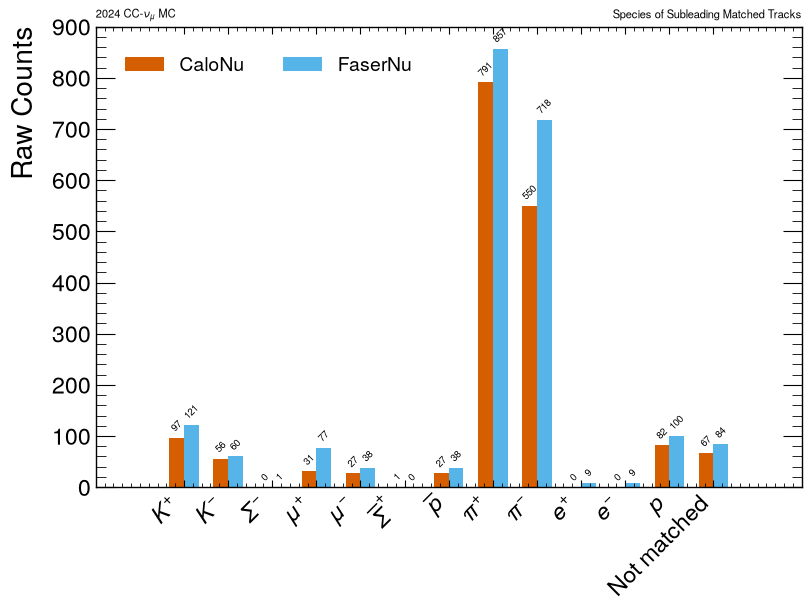

In [178]:
subleading_track_pdgs_caloNu = get_subleading_track_pdg(events_two_tracks_caloNu)
subleading_track_pdgs_faserNu = get_subleading_track_pdg(events_two_tracks_faserNu)

subleading_track_names_caloNu = get_particle_names(subleading_track_pdgs_caloNu)
subleading_track_names_faserNu = get_particle_names(subleading_track_pdgs_faserNu)

species = sorted(set(subleading_track_names_caloNu).union(set(subleading_track_names_faserNu)))
print(f"Species of subleading tracks: {species}")

species_counts_subleading = {
    "CaloNu": [0 for _ in range(len(species))],
    "FaserNu": [0 for _ in range(len(species))]
}
for sp in species:
    species_counts_subleading["CaloNu"][species.index(sp)] = subleading_track_names_caloNu.count(sp)
    species_counts_subleading["FaserNu"][species.index(sp)] = subleading_track_names_faserNu.count(sp)


fig, ax = plt.subplots(layout='constrained')

res = ax.grouped_bar(species_counts_subleading, tick_labels=species, group_spacing=1)
for container in res.bar_containers:
    ax.bar_label(container, padding=3, fontsize=7, rotation=45)

ax.legend(loc='upper left', ncols=3)
# rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
ax.set_ylabel("Raw Counts")
ax.set_title("Species of Subleading Matched Tracks", fontsize=8, loc="right")
ax.set_title(r"2024 CC-$\nu_\mu$ MC", loc="left", fontsize=8)

In [179]:
for f in mc_CaloNu_events.fields:
    print(f)

BCID
Calo0_E_EM
Calo0_E_dep
Calo0_baseline
Calo0_baseline_rms
Calo0_bcidtime
Calo0_charge
Calo0_localtime
Calo0_nMIP
Calo0_peak
Calo0_raw_charge
Calo0_raw_peak
Calo0_status
Calo0_triggertime
Calo0_width
Calo1_E_EM
Calo1_E_dep
Calo1_baseline
Calo1_baseline_rms
Calo1_bcidtime
Calo1_charge
Calo1_localtime
Calo1_nMIP
Calo1_peak
Calo1_raw_charge
Calo1_raw_peak
Calo1_status
Calo1_triggertime
Calo1_width
Calo2_E_EM
Calo2_E_dep
Calo2_baseline
Calo2_baseline_rms
Calo2_bcidtime
Calo2_charge
Calo2_localtime
Calo2_nMIP
Calo2_peak
Calo2_raw_charge
Calo2_raw_peak
Calo2_status
Calo2_triggertime
Calo2_width
Calo3_E_EM
Calo3_E_dep
Calo3_baseline
Calo3_baseline_rms
Calo3_bcidtime
Calo3_charge
Calo3_localtime
Calo3_nMIP
Calo3_peak
Calo3_raw_charge
Calo3_raw_peak
Calo3_status
Calo3_triggertime
Calo3_width
CaloNu0_E_EM
CaloNu0_E_dep
CaloNu0_baseline
CaloNu0_baseline_rms
CaloNu0_bcidtime
CaloNu0_charge
CaloNu0_localtime
CaloNu0_nMIP
CaloNu0_peak
CaloNu0_raw_charge
CaloNu0_raw_peak
CaloNu0_status
CaloNu0_tri